# 🎭 Sentiment Analysis — IMDB Movie Reviews

## Project Overview
Built a sentiment classifier that detects whether a movie 
review is positive or negative using NLP techniques.

## Model Performance
- **Accuracy: 84.60%**
- Trained on 4000 IMDB reviews
- Tested on 1000 reviews

## Key Findings
- Negative reviews use words like: bad, nothing, never, worst
- Positive reviews use words like: great, love, best, amazing
- Model struggles with character names and domain mismatch

## Tools Used
Python, Pandas, Scikit-learn, TF-IDF, WordCloud

## Author
**Faith Mwende** | [GitHub](https://github.com/Mwende-Fifi)

In [16]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [17]:
# Loading IMDB dataset using datasets library
from datasets import load_dataset

dataset = load_dataset("imdb")
df = pd.DataFrame(dataset['train'])

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSentiment distribution:")
print(df['label'].value_counts())

Shape: (25000, 2)

Columns: ['text', 'label']

Sentiment distribution:
label
0    12500
1    12500
Name: count, dtype: int64


In [18]:
# Exploring the data
# Map labels to readable names
df['sentiment'] = df['label'].map({0: 'negative', 1: 'positive'})

print("Sample positive review:")
print(df[df['sentiment']=='positive']['text'].iloc[0][:200])
print("Sample negative review:")
print(df[df['sentiment']=='negative']['text'].iloc[0][:200])

Sample positive review:
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emo
Sample negative review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev


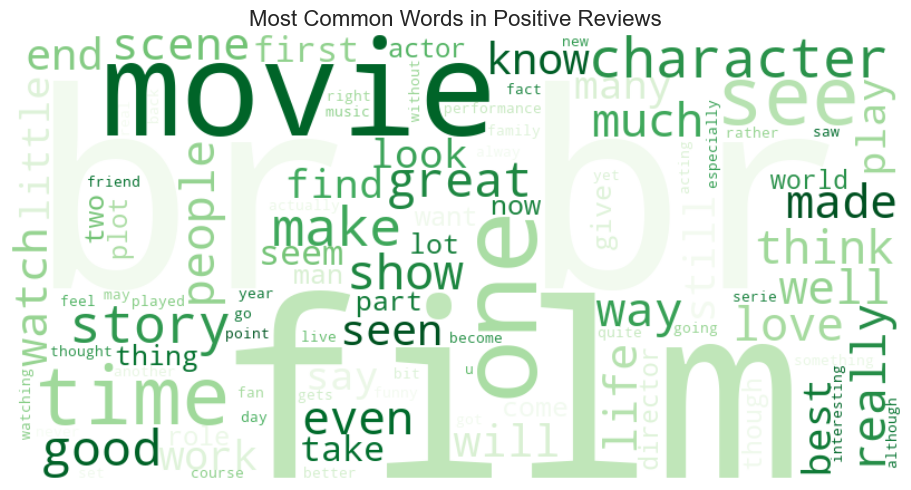

In [19]:
# Word Cloud for positive reviews
positive_text = ' '.join(df[df['sentiment']=='positive']['text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews', fontsize=16)
plt.tight_layout()
plt.show()

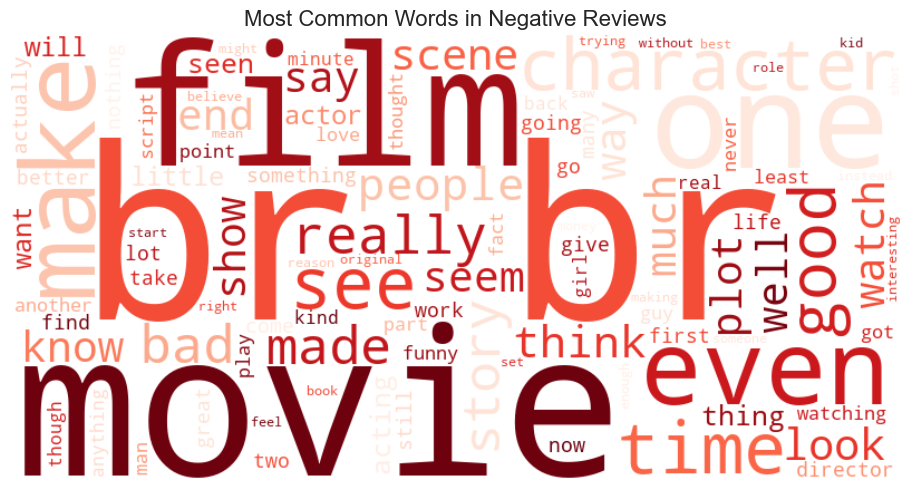

In [20]:
# Word Cloud for negative reviews
negative_text = ' '.join(df[df['sentiment']=='negative']['text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews', fontsize=16)
plt.tight_layout()
plt.show()

In [21]:
# Build sentiment classifier
# Use sample of 5000 for speed
df_sample = df.sample(5000, random_state=42)

X = df_sample['text']
y = df_sample['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text to numbers
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training set:", X_train_tfidf.shape)
print("Tesing set:", X_test_tfidf.shape)

Training set: (4000, 5000)
Tesing set: (1000, 5000)


In [22]:
# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Test the model
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Positive']))

Model Accuracy: 84.60%

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.88      0.81      0.84       516
    Positive       0.81      0.89      0.85       484

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



In [23]:
# Test with real sentences
def predict_sentiment(text):
    text_tfidf = tfidf.transform([text])
    prediction = model.predict(text_tfidf)[0]
    probability = model.predict_proba(text_tfidf)[0]

    sentiment = 'Positive' if prediction == 1 else 'Negative'
    confidence = max(probability) *  100

    print(f"Review: {text}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.1f}%\n")

# Testing
predict_sentiment("This movie was absolutely amazing l loved every minute")
predict_sentiment("Terrible film waste of time and money")
predict_sentiment("The acting was okay but the story was boring")

predict_sentiment("I loved watching the Industry especially with characters like 'Harper Stern and Eric Tao' on it")

Review: This movie was absolutely amazing l loved every minute
Sentiment: Positive
Confidence: 84.2%

Review: Terrible film waste of time and money
Sentiment: Negative
Confidence: 96.8%

Review: The acting was okay but the story was boring
Sentiment: Negative
Confidence: 85.5%

Review: I loved watching the Industry especially with characters like 'Harper Stern and Eric Tao' on it
Sentiment: Positive
Confidence: 69.8%

